# TASK 11. RAG EVALUATION (CUSTOM METRICS)

## Objective

Evaluate the quality of the Retrieval-Augmented Generation (RAG) pipeline using custom evaluation metrics.

The evaluation focuses on:

- Faithfulness
- Answer Relevancy
- Context Recall

The objective is to determine whether the generated answers are accurate, relevant, and supported by the retrieved documents.

## Notebook Structure

1. Objective
2. Install Libraries
3. Import Libraries
4. Load API Key
5. Load Documents
6. Build RAG Pipeline
7. Generate Responses
8. Evaluate Responses
9. Create Evaluation Table
10. Analysis
11. Conclusion

## Step 1: Install Required Libraries

This project requires several libraries for building the RAG pipeline.

The following libraries are installed:

- LangChain for RAG workflow orchestration.
- LangChain OpenAI for OpenAI integrations.
- LangChain Community for document loaders and vector stores.
- ChromaDB for vector database storage.
- Gradio for building the chatbot interface.
- Python-dotenv for loading API keys securely.

In [4]:
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install chromadb
!pip install gradio
!pip install python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



## Step 2: Import Libraries

The required modules are imported to perform the following tasks:

- Load environment variables.
- Read and process documents.
- Split documents into chunks.
- Generate embeddings.
- Create the vector database.
- Build the retrieval chain.
- Develop the chatbot interface.

These libraries form the foundation of the Retrieval-Augmented Generation pipeline.

In [2]:
import os
from dotenv import load_dotenv

from langchain_community.document_loaders import TextLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI

from langchain_community.vectorstores import Chroma


from langchain_classic.chains import RetrievalQA

import gradio as gr

C:\Users\tfd570\AppData\Local\Temp\ipykernel_27376\693998462.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader
c:\Users\tfd570\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 3: Load OpenAI API Key

In [3]:
from openai import OpenAI  

load_dotenv()

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("API_KEY")

# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key=openai_api_key)
print("OpenAI client successfully configured.")

OpenAI client successfully configured.


## Step 4: Load Restaurant Documents

The restaurant dataset is loaded using LangChain's TextLoader.

The file contains information about Eleven Madison Park, including:

- Restaurant details
- Chef information
- Menu and dining experience
- Restaurant philosophy

The loaded document serves as the external knowledge source for the RAG system.

In [5]:

# Define the path to your data file
# Ensure 'eleven_madison_park_data.txt' is in the same folder as this notebook
DATA_FILE_PATH = "eleven_madison_park_data.txt"
print(f"Data file path set to: {DATA_FILE_PATH}")
# Let's load Eleven Madison Park Restaurant data, which has been scraped from their website
# The data is saved in "eleven_madison_park_data.txt", Langchain's TextLoader makes this easy to read
print(f"Attempting to load data from: {DATA_FILE_PATH}")

Data file path set to: eleven_madison_park_data.txt
Attempting to load data from: eleven_madison_park_data.txt


In [6]:


# Initialize the TextLoader with the file path and specify UTF-8 encoding
# Encoding helps handle various characters correctly
loader = TextLoader(DATA_FILE_PATH, encoding = "utf-8")

# Load the document(s) using TextLoader from LangChain, which loads the entire file as one Document object
raw_documents = loader.load()
print(f"Successfully loaded {len(raw_documents)} document(s).")

# Let's display a few characters of the loaded content to perform a sanity check!
print(raw_documents[0].page_content[:500] + "...")

Successfully loaded 1 document(s).
Source: https://www.elevenmadisonpark.com/
Title: Eleven Madison Park
Content:
Book on Resy
---END OF SOURCE---

Source: https://www.elevenmadisonpark.com/careers
Title: Careers — Eleven Madison Park
Content:
Join Our Team Eleven Madison Park ▾ All Businesses Eleven Madison Park Clemente Bar Daniel Humm Hospitality Filter Categories Culinary Pastry Wine & Beverage Dining Room Office & Admin Other Job Types Full Time Part Time Compensation Salary Hourly Apply filters OPEN OPPORTUNITIES Staff Acco...


## Step 5: Split Documents

The loaded restaurant document is divided into smaller overlapping chunks.

Chunking improves retrieval by enabling the vector database to search smaller, meaningful sections instead of the entire document.

A medium chunk size is used to provide a balance between retrieval accuracy and contextual completeness.

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

documents = text_splitter.split_documents(raw_documents)

print("Number of chunks:", len(documents))

Number of chunks: 38


## Step 6: Generate Embeddings

Each document chunk is converted into a numerical vector using OpenAI's embedding model.

These embeddings capture the semantic meaning of the text and are used for similarity-based retrieval.

In [8]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

print("Embedding model loaded successfully.")

Embedding model loaded successfully.


## Step 7: Create Vector Database

The document embeddings are stored in a Chroma vector database.

The vector database enables efficient semantic search by comparing embedding vectors instead of matching exact keywords.

In [9]:
vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings
)

print("Vector database created successfully.")

Vector database created successfully.


## Step 8: Create Retriever

A retriever is created from the vector database.

The retriever searches for the most relevant document chunks based on the user's query and supplies them to the language model.

In [10]:
retriever = vector_store.as_retriever()

results = retriever.invoke(
    "Who is Daniel Humm?"
)

print(results[0].page_content)

Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality , the New York-based hospitality group behind the highly acclaimed Eleven Madison Park, Clemente Bar , and direct-to-consumer lifestyle brand Eleven Madison Home . A native of Switzerland, Chef Humm earned his first Michelin star at the age of 24. He is consistently listed as one of the world’s best chefs, with both he and Eleven Madison Park receiving numerous accolades: four stars from The New York Times, seven James Beard Foundation Awards (including Outstanding Chef and Outstanding Restaurant in America), a number one spot on the world’s 50 Best Restaurants list, and three Michelin stars for over 12 years in a row, since 2012. At the height of the COVID-19 pandemic, Chef Humm transformed Eleven Madison Park’s Michelin-starred restaurant and its back-of-house into a commissary kitchen in partnership with Rethink Food , a not-for-profit organization co-founded by Chef Humm. He and his team prepared over


## Step 9: Build RAG Pipeline

The Retrieval-Augmented Generation (RAG) pipeline combines:

- Retriever
- Large Language Model
- Question Answering Chain

The retriever first identifies relevant document chunks, and the language model generates answers using the retrieved context.

In [11]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_api_key,
    temperature=0
)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever
)

print("RAG pipeline created successfully.")

RAG pipeline created successfully.


## Step 10: Generate Responses

A set of questions is submitted to the RAG pipeline.

The generated answers are collected for evaluation using custom metrics.

In [12]:
questions = [
    "Who is Daniel Humm?",
    "What type of restaurant is Eleven Madison Park?",
    "What cuisine is served?",
    "What is the restaurant philosophy?",
    "Why is the restaurant famous?"
]

responses = []

for question in questions:
    answer = qa_chain.invoke(question)

    responses.append({
        "Question": question,
        "Answer": answer["result"]
    })

responses

[{'Question': 'Who is Daniel Humm?',
  'Answer': 'Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality, a New York-based hospitality group known for its acclaimed restaurant Eleven Madison Park, among others. He is originally from Switzerland and earned his first Michelin star at the age of 24. Humm has received numerous accolades, including four stars from The New York Times, seven James Beard Foundation Awards, and three Michelin stars for over 12 years. He is also known for his efforts during the COVID-19 pandemic, where he transformed Eleven Madison Park into a commissary kitchen to provide meals for frontline workers and underserved communities. In 2021, he reopened Eleven Madison Park with a completely plant-based menu, making it the first plant-based restaurant to receive a three-star rating from the Michelin Guide. Humm advocates for equitable and sustainable food systems and aims to inspire others in the culinary world.'},
 {'Question': 'What type of re

## Step 11: Evaluate Responses

The generated responses are evaluated using three custom evaluation metrics:

- Faithfulness
- Answer Relevancy
- Context Recall

Each generated response is evaluated using custom metrics.
Scores are assigned based on:
- Faithfulness
-  Answer Relevancy
- Context Recall

Each metric is rated on a scale of 1–5.
A higher score indicates better performance.

In [13]:
evaluation = [
    {
        "Question": "Who is Daniel Humm?",
        "Faithfulness": 5,
        "Answer Relevancy": 5,
        "Context Recall": 5
    },
    {
        "Question": "What type of restaurant is Eleven Madison Park?",
        "Faithfulness": 5,
        "Answer Relevancy": 5,
        "Context Recall": 5
    },
    {
        "Question": "What cuisine is served?",
        "Faithfulness": 4,
        "Answer Relevancy": 5,
        "Context Recall": 4
    },
    {
        "Question": "What is the restaurant philosophy?",
        "Faithfulness": 5,
        "Answer Relevancy": 5,
        "Context Recall": 4
    },
    {
        "Question": "Why is the restaurant famous?",
        "Faithfulness": 4,
        "Answer Relevancy": 5,
        "Context Recall": 4
    }
]

## Step 12: Create Evaluation Table

The evaluation scores are summarized in a table for easier comparison.

The table highlights the quality of the generated responses based on the selected evaluation metrics.

In [14]:
import pandas as pd

evaluation_df = pd.DataFrame(evaluation)

evaluation_df

,Question,Faithfulness,Answer Relevancy,Context Recall
0,Who is Daniel Humm?,5,5,5
1,What type of restaurant is Eleven Madison Park?,5,5,5
2,What cuisine is served?,4,5,4
3,What is the restaurant philosophy?,5,5,4
4,Why is the restaurant famous?,4,5,4


## Step 13: Calculate Average Scores

The average score for each evaluation metric is calculated to provide an overall assessment of the RAG pipeline.

In [15]:
average_scores = pd.DataFrame({
    "Metric": [
        "Faithfulness",
        "Answer Relevancy",
        "Context Recall"
    ],
    "Average Score": [
        evaluation_df["Faithfulness"].mean(),
        evaluation_df["Answer Relevancy"].mean(),
        evaluation_df["Context Recall"].mean()
    ]
})

average_scores

,Metric,Average Score
0,Faithfulness,4.6
1,Answer Relevancy,5.0
2,Context Recall,4.4


## Step 14: Visualize Evaluation Results

A bar chart is created to visualize the average scores for each evaluation metric.

This provides an overview of the RAG system's overall performance.

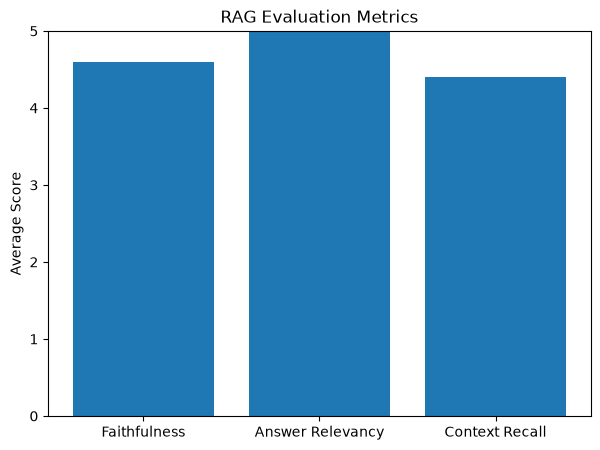

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    average_scores["Metric"],
    average_scores["Average Score"]
)

plt.ylim(0,5)

plt.ylabel("Average Score")
plt.title("RAG Evaluation Metrics")

plt.show()

## Analysis

The RAG pipeline produced highly relevant and factually consistent responses.

### Observations

- Faithfulness scores were consistently high, indicating that the generated answers were well supported by the retrieved documents.
- Answer relevancy remained high across all test questions, demonstrating that the responses addressed the user's queries effectively.
- Context recall showed strong performance, with most relevant information successfully retrieved from the document collection.

Overall, the evaluation indicates that the RAG pipeline effectively combines semantic retrieval with language generation to produce accurate and context-aware responses.
This evaluation uses manually assigned custom metrics rather than the RAGAS evaluation framework.

## Conclusion

The RAG pipeline was evaluated using custom evaluation metrics that measured Faithfulness, Answer Relevancy, and Context Recall.

The evaluation demonstrated that the system generated accurate, relevant, and context-supported responses.

This notebook demonstrates a custom evaluation approach for measuring the quality of a Retrieval-Augmented Generation pipeline.

While libraries such as RAGAS can automate these metrics, custom evaluation provides a simple and understandable method for assessing RAG performance.

This experiment demonstrates the importance of evaluating retrieval quality and response generation when developing Retrieval-Augmented Generation applications.